#Suffix Tree Construction and the Longest Repeated Substring Problem

The following problem appeared as an assignment in the **coursera course BioInformatics Algorithms II (by UCSD)**. The following description of the problem is taken from the course assignment, *Rosalind* (http://rosalind.info/) and *Stepik* (https://stepik.org/).

In [5]:
#ipython nbconvert pcaiso.ipynb
%matplotlib inline

from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')

The following problems define a couple of data structures for fast pattern matching: a collection of (smaller) strings *Patterns* that we wish to match against a (larger) genome string *Text*.

## Creating a Trie from Patterns
we would like to organize *Patterns* into a data structure to prevent multiple passes down *Text* and to reduce the runtime. To this end, we will consolidate *Patterns* into a *directed tree* called a *trie* (pronounced “try”), which is written
*Trie(Patterns)* and has the following properties (example shown in the next figure).

1. The trie has a single node with indegree 0, called the root.
2. Each edge of Trie(Patterns) is labeled with a letter of the alphabet.
3. Edges leading out of a given node have distinct labels.
4. Every string in Patterns is spelled out by concatenating the letters along some path from
5. the root downward.
6. Every path from the root to a leaf, or node with outdegree 0, spells a string from Patterns.

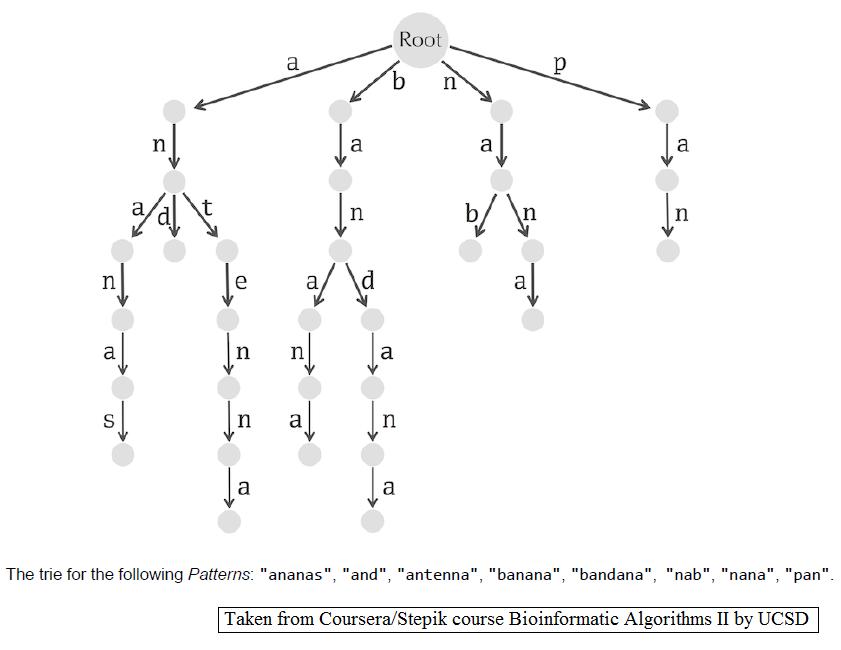

In [2]:
from IPython.display import Image
Image(filename='C:\\courses\\Coursera\\Past\\BioInformatics\\BioInformatics Algorithms II\\PA\\im00.png')

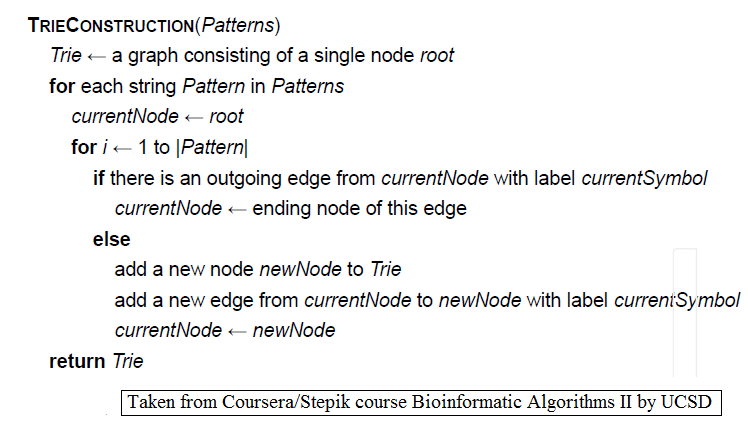

In [5]:
Image(filename='C:\\courses\\Coursera\\Past\\BioInformatics\\BioInformatics Algorithms II\\PA\\im01.png', width=600, height=600)

## Creating a Suffix Trie

A *suffix trie*, denoted *SuffixTrie(Text)*, is the trie formed from all suffixes of *Text* (see figure below). A dollar sign ("$") is appended to *Text* in order to mark the end of Text. We will also label each leaf of the resulting trie by the starting position of the suffix whose path through the trie ends at this leaf (using 0 based indexing). This way, when we arrive at a leaf, we will immediately know where this suffix came from in Text.

The following pseudocode constructs the suffix trie of a string *Text* by traversing the suffixes of Text from longest to
shortest. Given a suffix, it attempts to spell the suffix downward by following edge labels as far as possible until it can go no further. At that point, it adds the rest of the suffix to the trie in the form of a path to a leaf, along with the position of each symbol in the suffix.

There are *|Text|* suffixes of *Text*, ranging in length from *1* to *|Text|* and having total length $O(|Text|^2)$. Thus, we need to reduce both the construction time and memory requirements of suffix tries to make them practical. We can reduce the number of edges in *SuffixTrie(Text)* by *combining the edges* on any *nonbranching path* into a single edge. We then label this edge with the concatenation of symbols on the consolidated edges, as shown in the figure below. The resulting data structure is called a suffix tree, written *SuffixTree(Text)*. 

Prove: A *SuffixTree(Text)* has exactly *|Text|* leaves (since each leaf correspond to a suffix of *Text*) and at most *|Text|* other nodes (in the worst case *Text* can be repetition of the same symbol, in which case the suffix tree will be linear and it will have *|Text|* other nodes).

## Creating a Suffix Tree

Given a string *s* having length *L*, recall that its suffix tree *T* is defined by the following properties:

1. *T* is a *rooted tree* having exactly *L+1* leaves.
2. Every edge of *T* is labeled with a substring of *s\$*, where *s\$* is the string formed by adding a placeholder symbol *\$* to the end of *s*.
3. Every *internal node* of *T* other than the *root* has at least two children; i.e., it has degree at least 3.
4. The substring labels for the edges leading down from a node to its children must begin with different symbols.
5. By concatenating the substrings along edges, each path from the *root* to a *leaf* corresponds to a *unique suffix* of *s*.

The following figures show example *Suffix Trie* and *Suffix Tree* created from a *Text* and also the algorithm pseudocodes. 

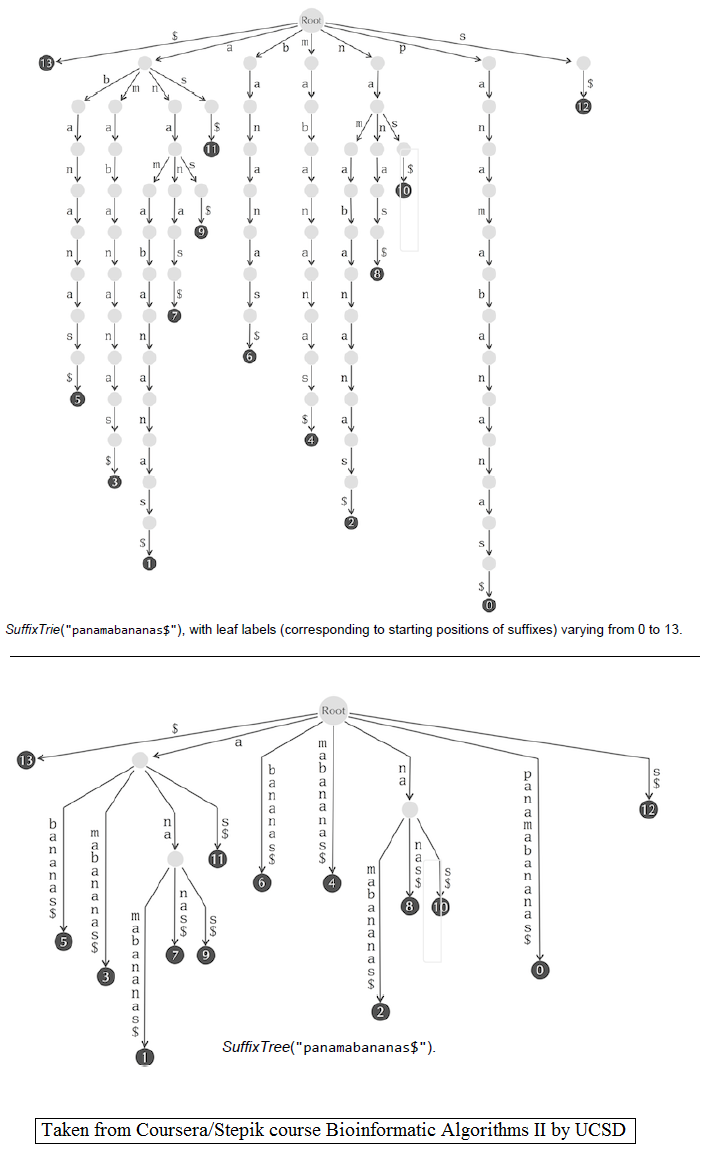

In [6]:
Image(filename='C:\\courses\\Coursera\\Past\\BioInformatics\\BioInformatics Algorithms II\\PA\\im0.png')

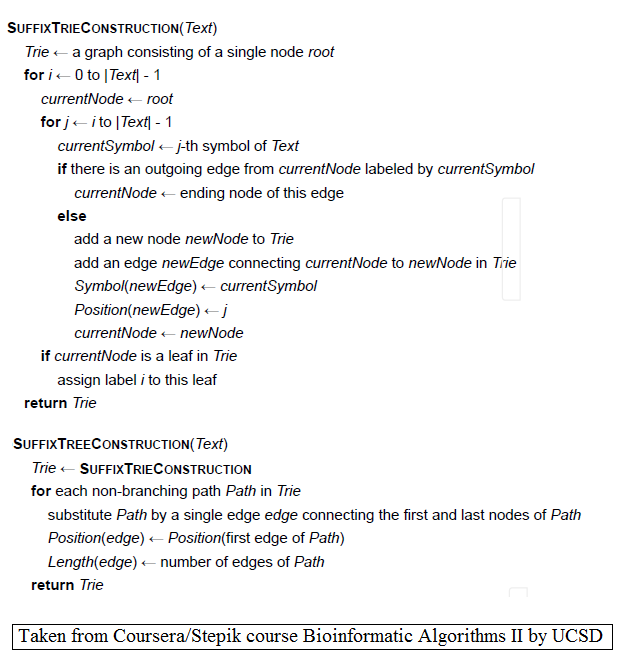

In [7]:
Image(filename='C:\\courses\\Coursera\\Past\\BioInformatics\\BioInformatics Algorithms II\\PA\\im1.png')

The following figures show how the suffix tree is constructed for the *Text* *panamabananas\$* as all the suffixes are inserted into the suffix tree starting from the largest to the smallest suffix.

The next figures show how the suffix tree is constructed for the *genome Text* *ATAAATG\$*.

The next figures show how the suffix tree is constructed for the *genome Text* *TCTGAGCCCTACTGTCGAGAAATATGTATCTCGCCCCCGCAGCTT\$*.

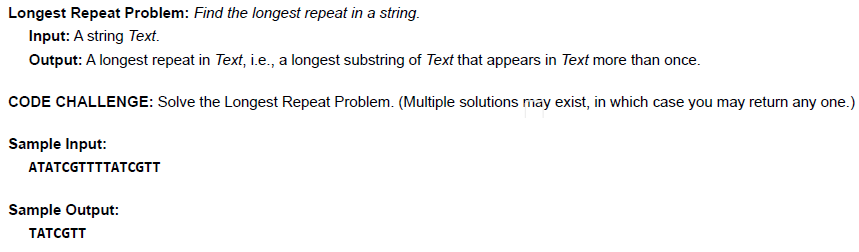

In [8]:
Image(filename='C:\\courses\\Coursera\\Past\\BioInformatics\\BioInformatics Algorithms II\\PA\\im2.png')

As we can see from the following figure, in order to find any *repeated pattern* inside the *Text*,
1. We need to start at the root from the suffix tree and traverse towards the internal nodes (concatenating all the edges from the root to any of the internal nodes represents a repeated pattern inside the text).
2. Choose the longest of all such texts.

In the next figure the paths colors red, blue and green each starting from the root and ending in some *internal node* of the *suffix tree* represent *repeated patterns*.

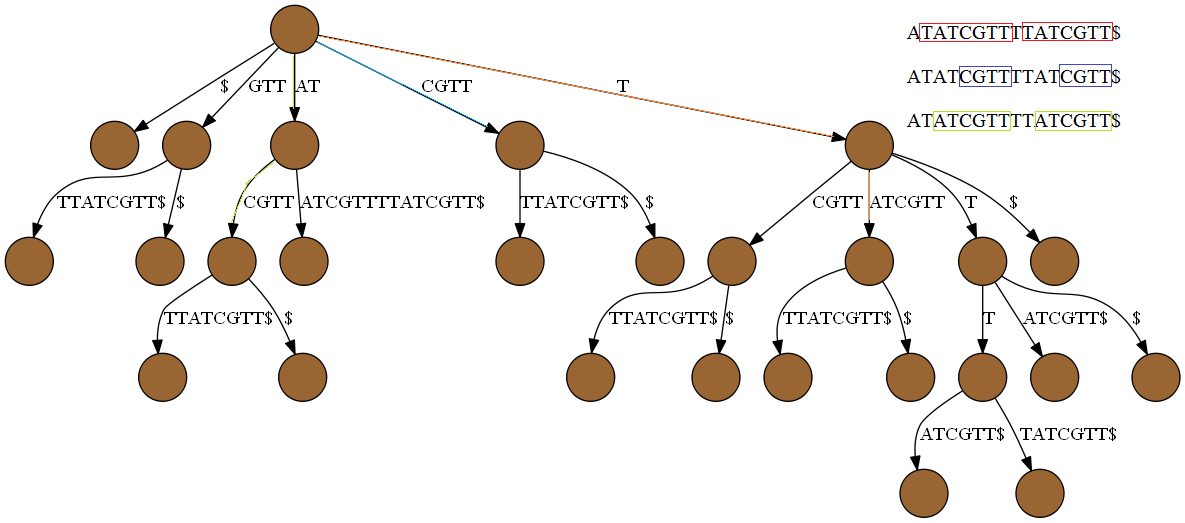

In [10]:
Image(filename='C:\\courses\\Coursera\\Past\\BioInformatics\\BioInformatics Algorithms II\\PA\\lptree.png')